# Second Project

## Introduction
This mini project focuses on the application of Seismic Dislocation and Horizontal Displacement within an infinite, homogeneous, and isotropic elastic medium. The simulation models a seismic event originating from a rectangular source surface, $\Sigma_1$, which undergoes a time-evolving dislocation in the direction of the horizontal $x_1$ axis.
### Problem Description
We consider an infinite, homogeneous, and isotropic elastic medium. A rectangular surface, denoted as $\Sigma_1$, undergoes a time-evolving dislocation in the direction of the horizontal axis $x_1$.The objective is to calculate and animate the horizontal displacements (along the $x_1$ axis) on two parallel surfaces located at different depths:

$\Sigma_2$: Located at $z = 10$ km.

$\Sigma_3$: Located at $z = 15$ km. 

### Model Parameters: 
P-wave velocity ($\alpha$): $5.6$ km/s  

S-wave velocity ($\beta$): $3.2$ km/s. 

Density ($\rho$): $2.2\text{ g/cm}^{3}$

### Parameters and Discretization:
Temporal Domain: $t \in [0, 12]$ seconds, discretized into 300 equidistant points to ensure a smooth animation.

Spatial Grid ($x_1, x_2$): The $x_1$ axis covers the range $[-0.5, 0.5]\text{ km}$ with 64 points. The $x_2$ axis covers the range $[-1.0, 1.0]\text{ km}$ with 64 points.

Observation Depths ($x_3$): Measurements are taken at $z=0\text{ km}$ (source), $z=10\text{ km}$, and $z=15\text{ km}$.

### Dislocation Function on $\Sigma_1$

The evolution of the dislocation at the source surface $\Sigma_1$ ($z=0$) is given by the formula:
$$[u_1](x_1, x_2, t) = (\sin x_1 + \cos x_2) \exp(-t^2 + 5t - 4) \sin(4t^3)$$

## Import Libraries

In [2]:
import numpy as np
from matplotlib import pyplot as plt, animation
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Creating the animation.

In [4]:
plt.rcParams["figure.figsize"] = [5.00, 10.0]
plt.rcParams["pcolor.shading"] = 'auto'
a = 5600
b = 3200

def create_animation(t,x1,x2,tensor0,tensor1,tensor2,filename='wave3d.gif'):
    n = len(t)
    fig, ax = plt.subplots(3)
    ax[0].set_title('z=0 motion in ax x1')
    ax[1].set_title('z=10km motion in ax x1')
    ax[2].set_title('z=15km motion in ax x1')
    pcolor_ax0 = ax[0].pcolor(x1, x2, tensor0[0,:,:], vmin=tensor0.min(), vmax=tensor0.max())
    pcolor_ax1 = ax[1].pcolor(x1, x2, tensor1[0,:,:], vmin=tensor1.min(), vmax=tensor1.max())
    pcolor_ax2 = ax[2].pcolor(x1, x2, tensor2[0,:,:], vmin=tensor2.min(), vmax=tensor2.max())
    div0 = make_axes_locatable(ax[0])
    div1 = make_axes_locatable(ax[1])
    div2 = make_axes_locatable(ax[2])
    cax0 = div0.append_axes('right', size='5%', pad=0.2)
    cax1 = div1.append_axes('right', size='5%', pad=0.2)
    cax2 = div2.append_axes('right', size='5%', pad=0.2)
    def update(i):
        pcolor_ax0.set_array(tensor0[i, :, :].flatten())
        pcolor_ax1.set_array(tensor1[i, :, :].flatten())
        pcolor_ax2.set_array(tensor2[i, :, :].flatten())
    fig.colorbar(pcolor_ax0, cax=cax0)
    fig.colorbar(pcolor_ax1, cax=cax1)
    fig.colorbar(pcolor_ax2, cax=cax2)
    anim = animation.FuncAnimation(fig, update, interval=1000*t[-1]/len(t), frames=n)
    anim.save('1.gif')

## Creating the solutions for Primary and Secondary waves.

In [5]:
def g(x,r):
    return x/r

def uhat_prime1(t,r):
    return ((1/2)*(np.sin(1)-np.sin(-1)-4*np.cos(1/2))*np.exp(-(t-r/a)**2 +5*(t-r/a)-4))*((-2*(t-r/a)+5)*np.sin(4*(t-r/a)**3)+np.cos(4*(t-r/a)**3)*12*((t-r/a)**2))

def uhat_prime2(t,r):
    return ((1/2)*(np.sin(1)-np.sin(-1)-4*np.cos(1/2))*np.exp(-(t-r/b)**2 +5*(t-r/b)-4))*((-2*(t-r/b)+5)*np.sin(4*(t-r/b)**3)+np.cos(4*(t-r/b)**3)*12*((t-r/b)**2))

## Temporal Domain and Spatial Grid. 

In [7]:
t = np.linspace(0,12,300)  
x1 = np.linspace(-1/2, 1/2, 64) 
x2 = np.linspace(-1, 1, 64)  
x3 = 0.0  # 0 Km
x4 = 10000.0   # 10 Km
x5 = 15000.0   # 15 Km

u1 = np.zeros((len(t),len(x1),len(x2)))
u2 = np.zeros((t.shape[-1],x1.shape[-1],x2.shape[-1]))
u2p = np.zeros((len(t),len(x1),len(x2)))
u2s = np.zeros((len(t),len(x1),len(x2)))
u3 = np.zeros((t.shape[-1],x1.shape[-1],x2.shape[-1]))
u3p = np.zeros((len(t),len(x1),len(x2)))
u3s = np.zeros((len(t),len(x1),len(x2)))

## Calculating the solutions for each level of surface and then plotting the animation.

MovieWriter ffmpeg unavailable; using Pillow instead.


<Figure size 500x1000 with 0 Axes>

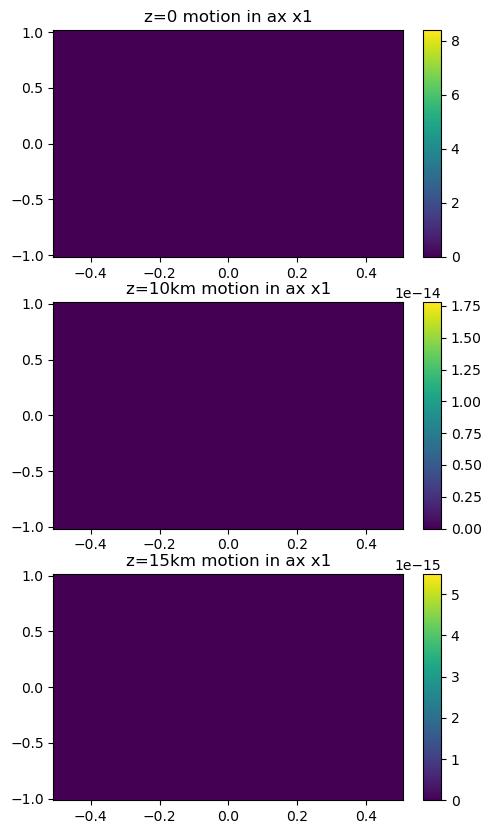

<Figure size 500x1000 with 0 Axes>

In [8]:
for i, _t in enumerate(t):
    for j, _x1 in enumerate(x1):
        for k, _x2 in enumerate(x2):
            r2 = np.sqrt(_x1**2 + _x2**2 + x4**2)
            r3 = np.sqrt(_x1**2 + _x2**2 + x5**2)
            g11, g22, g33 = g(_x1,r2), g(_x2,r2), g(x4,r2)
            g111, g222, g333 = g(_x1,r3), g(_x2,r3), g(x5,r3)
            u1[i,j,k] = (1/2)*(np.sin(1)-np.sin(-1)-4*np.cos(1/2))*(np.exp(-_t**2 +5*_t -4))*np.sin(4*_t**3)
            u2p = uhat_prime1(_t,r2)
            u2s = uhat_prime2(_t,r2)
            u3p = uhat_prime1(_t,r3)
            u3s = uhat_prime2(_t,r3)
            u2[i,j,k] =(-g11**2 * g33 * u2p/r2)*(1/(np.pi*a)) + (g11**2 * g33 * u2s/r2)*(1/(np.pi*b))  #z=10km
            u3[i,j,k] = (-g111**2 * g333 * u3p/r3)*(1/(np.pi*a))+(g111**2 * g333 * u3s/r3)*(1/(np.pi*b))  #z=15km

create_animation(t,x1,x2,np.abs(u1),np.abs(u2),np.abs(u3))

plt.figure()
